In [1]:
from models import prepare_all, filter_high_correlation, calculate_optimal_params, filter_features, train_walk_forward_2level, tune_threshold_wf, evaluate_model_classification, tune_threshold_wf, tune_threshold
from target import target_triple_barrier_realistic, apply_liquidity_filter
from load import save_trading_model_2level
import pandas as pd
from models_def import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir
import torch.nn as nn
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from tqdm import tqdm
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier

In [2]:
asset_list = ["bp1", "cl1", "es1", "gc1", "ibex1"]
ASSET = asset_list[4]
MINUTES = 60
RETURN_HORIZON_MIN  = MINUTES * 2
TARGET_COLUMN_TRIPLE = 'target_class'

In [3]:
df_final, spec = prepare_all(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")
info_json = pd.read_json("../Data/futuros_specs_extend.json")


Dataset 'mfxi1' imported with 4206437 rows
Limpieza ibex1 completada. Filas restantes: 4205515


In [4]:
exclude_cols_triple = [
    # Identificadores / temporales no cíclicos
    "datetime", "dtyyyymmdd", "trading_date", "ticker", "per", "openint",

    # OHLCV raw (el modelo no debería ver precios absolutos)
    "open", "high", "low", "close", "volume",

    # Targets
    "target_bin", f"target_logret_{MINUTES}", f"target_ret_{MINUTES}", f"target_ticks_{MINUTES}",
]
exclude_more = [
    # --- NO ESTACIONARIAS (Precios Absolutos) ---
    "open_day",           # El culpable nº 1 (Primer precio del día)
    "bb_std",             # Si es la desviación estándar en USD, varía con el precio
    "true_range",         # Es volatilidad en USD, no en % ni relativa
    
    # --- VOLUMEN ABSOLUTO (Crecen con el tiempo) ---
    "volume_cum",         # Volumen acumulado total
    "vpt",                # Volume Price Trend (usa precios y volumen raw)
    "obv",                # On-Balance Volume (es una suma acumulativa infinita)
    "ad",                 # Accumulation/Distribution (ídem que OBV)
    
    # --- REDUNDANTES / ALTA CORRELACIÓN ---
    # Si tienes 'hour_sin' y 'hour_cos', excluye las raw para no confundir a la red
    "hour", "minute", "dayofweek", "day", "month" 
]
exclude_cols_triple.extend(exclude_more)
feature_cols_triple = [c for c in df_final.columns if c not in exclude_cols_triple]

In [ ]:
if ASSET == 'ibex1':
    code = ASSET[:4].upper()
else:
    code = ASSET[:2].upper()
df_final_triple_real = target_triple_barrier_realistic(df_final, info_json[code].to_dict(), return_horizon_min=RETURN_HORIZON_MIN, sampling_minutes=MINUTES, profit_factor=1.8, tp_atr_mult=1.4, sl_atr_mult=1.2)
df_final_triple_real["target_class"] = df_final_triple_real[f"target_tb_{RETURN_HORIZON_MIN}m"]
df_final_triple_liquid = apply_liquidity_filter(df_final_triple_real)

In [6]:
df_final_triple_liquid[f"target_tb_{RETURN_HORIZON_MIN}m"].value_counts()

target_tb_120m
1.0    36815
0.0    11859
2.0     9044
Name: count, dtype: int64

In [7]:
# Úsalo solo con las features, no con el target
features_to_remove = filter_high_correlation(df_final_triple_liquid[feature_cols_triple])
print(f"Eliminando {len(features_to_remove)} features redundantes")

Eliminando 35 features redundantes


In [8]:
# --- Ejemplo de uso para velas de 1 Hora (60 min) ---
params = calculate_optimal_params(df_final_triple_liquid, sampling_minutes=60, horizon_min=120)
print(f"Configuración sugerida:\n{params}")

Configuración sugerida:
{'lookback': 36, 'train_size': 7000, 'test_size': 1000, 'gap': 2}


In [9]:
features_to_use = [f for f in feature_cols_triple if f not in features_to_remove]

In [10]:
# 1. Preparar datos (importante usar los mismos que vería el modelo)
X = df_final_triple_liquid[features_to_use]
y = df_final_triple_liquid[TARGET_COLUMN_TRIPLE] # OJO: Lasso es para regresión, si es clasificación usa LogisticRegression(penalty='l1')

# 2. ESCALAR ES OBLIGATORIO
# LASSO penaliza el tamaño de los coeficientes; si una variable tiene números 
# muy grandes, el modelo la penalizará por error.
sc = RobustScaler()
X_scaled = sc.fit_transform(X)

X_sample, y_sample = resample(
    X_scaled, y,
    n_samples=20_000,
    stratify=y,
    random_state=42
)

sel = SelectFromModel(
    RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    threshold="median"  # elimina la mitad menos importante
)
sel.fit(X_scaled, y)  # usa todos los datos, no necesita submuestra

features_finales_test = np.array(features_to_use)[sel.get_support()]
print(f"Features seleccionadas ({len(features_finales_test)}):")
print(features_finales_test)

Features seleccionadas (47):
['high_cum' 'hour_sin' 'hour_cos' 'adx' 'range_mean' 'obv_norm'
 'obv_roc_5' 'obv_roc_10' 'obv_ema_10' 'obv_z' 'obv_rel' 'relative_volume'
 'clv' 'ad_norm' 'ad_roc_5' 'ad_roc_10' 'ad_ema_10' 'ad_z' 'ad_delta'
 'mfi' 'cmf' 'volume_delta' 'volume_range' 'volume_price' 'return_lag_1'
 'return_lag_5' 'return_lag_10' 'return_lag_20' 'return_mean_5'
 'return_std_5' 'return_z_5' 'return_std_10' 'return_std_20' 'wick_ratio'
 'bb_width' 'rolling_skew_10' 'rolling_kurt_10' 'rolling_skew_20'
 'rolling_kurt_20' 'atr_norm' 'atr_z' 'vol_vol_ratio' 'upper_wick_pct'
 'dist_high_cum_ticks' 'dist_low_cum_ticks' 'vol_vs_body'
 'vol_weight_intraday']


In [15]:
results, results_by_fold, model_l1, model_l2, sc = train_walk_forward_2level(
    df_final_triple_liquid,
    features_finales_test,
    TARGET_COLUMN_TRIPLE,
    model_class_l1=GoldLSTM_L1_Move,
    model_class_l2=GoldLSTM_L2_Dir,
    train_size=params["train_size"],
    test_size=params["test_size"],
    gap=params["gap"],
    lookback=24,
    epochs=15,
    batch_size=256,
    lr=5e-4,
    threshold_move=0.7,
    threshold_dir=None
)

WF 2-Level: 100%|██████████| 50/50 [04:04<00:00,  4.88s/it]


📊 --- CLASIFICACIÓN POR CLASE ---
              precision    recall  f1-score   support

    SELL (0)       0.26      0.20      0.23     10237
    HOLD (1)       0.71      0.73      0.72     32002
     BUY (2)       0.23      0.27      0.25      7761

    accuracy                           0.55     50000
   macro avg       0.40      0.40      0.40     50000
weighted avg       0.54      0.55      0.55     50000



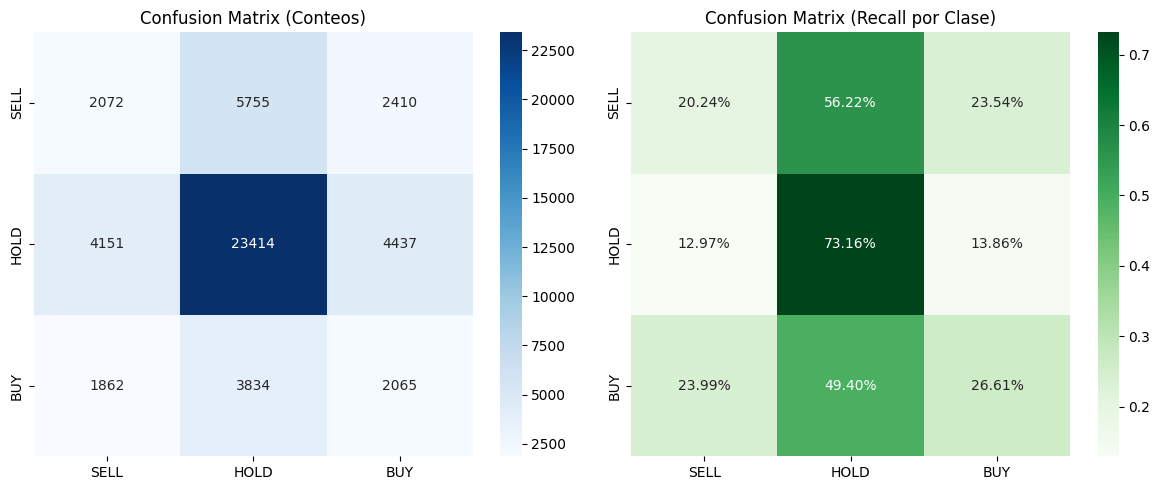


⭐ Métricas Globales:
Accuracy: 0.5510
F1-Score (Macro): 0.3981  <-- Si es < 0.33, el modelo es puro azar


{'accuracy': 0.55102, 'f1_macro': 0.398085803050051}

In [16]:
evaluate_model_classification(results)

In [17]:
best_threshold_by_fold = tune_threshold_wf(results_by_fold)

Threshold óptimo (train folds): 0.70 → F1=0.3940
F1 en val folds con ese threshold: 0.4046
Degradación: -0.0107 ✅ estable


In [20]:
results_gru, results_gru_by_fold, model_l1_gru, model_l2_gru, sc_gru = train_walk_forward_2level(
    df_final_triple_liquid,
    features_finales_test,
    TARGET_COLUMN_TRIPLE,
    model_class_l1=GoldGRU_L1_Move,   # ← GRU
    model_class_l2=GoldGRU_L2_Dir,    # ← GRU
    train_size=params["train_size"],
    test_size=params["test_size"],
    gap=params["gap"],
    lookback=24,
    epochs=15,
    batch_size=256,
    lr=5e-4,
    threshold_move=0.70,
    threshold_dir=None
)

WF 2-Level: 100%|██████████| 50/50 [03:45<00:00,  4.52s/it]


In [21]:
best_threshold_by_fold = tune_threshold_wf(results_gru_by_fold)

Threshold óptimo (train folds): 0.70 → F1=0.4021
F1 en val folds con ese threshold: 0.4079
Degradación: -0.0058 ✅ estable


In [22]:
model_params = {"input_dim": len(features_finales_test), "output_dim": 2}

save_trading_model_2level(
    model_l1, model_l2, sc,
    features_finales_test,
    model_params,
    path=f"../Models/{ASSET}/trading_model_lstm_2level"
)

# Para el GRU cuando lo tengas:
save_trading_model_2level(
    model_l1_gru, model_l2_gru, sc_gru,
    features_finales_test,
    model_params,
    path=f"../Models/{ASSET}/trading_model_gru_2level"
)

✅ Modelos L1 y L2 guardados en: ../Models/ibex1/trading_model_lstm_2level
✅ Modelos L1 y L2 guardados en: ../Models/ibex1/trading_model_gru_2level
